# Generating & Validating the Synthetic Data

The notebook is organized into two parts. **Part 1** generates the panel: accounts, macroeconomic conditions, trips, prices, customer behavior, and revenue. **Part 2** validates it, confirming the panel is usable and locating the partial/full label boundary. A fully synthetic, 50,000-account panel was built for the international roaming pricing case study, including accounts, macroeconomic conditions, trips, prices, customer behavior, and revenue. The data was validated before any downstream modeling was performed. No proprietary data was used anywhere in this project; every value was generated from parameters chosen to produce plausible behavior.

The data was generated from an explicit behavioral process, so each account's underlying price sensitivity and travel propensity was known by construction rather than estimated. This made it possible to evaluate downstream model performance against the parameters that actually generated the data, providing a direct test of parameter recovery rather than relying solely on predictive accuracy. In addition, randomness was layered intentionally, with account heterogeneity, a shared macro path, trip-level draws, and choice noise each contributing separately. Concentrating noise in a single component can produce models that perform unrealistically well in testing and understate the challenges they may face on real-world data.


---

## Part 1 · Generating the Synthetic Data

This part runs in seven steps, each depending only on the ones above it.

1. **Accounts**: structure (lines, tenure, plan, business flag) and two latent traits: travel propensity and price sensitivity.
2. **Macro path**: 24 months of an AR(1) economic index; converted to a travel-volume multiplier applied to everyone at once.
3. **Trips**: Poisson draws per account-month, scaled by propensity × seasonality × macro. Each trip gets a destination, a party size, and a duration.
4. **Effective price**: the historical price variation the model will eventually learn from. Without variation there is nothing to estimate, so this is generated explicitly rather than assumed.
5. **Behavioral state**: a multinomial logit over the five states, driven by the account's latent sensitivity and the price it faced.
6. **Magnitude**: for the two states that need sizing (reduce, increase), how many lines and days were actually bought.
7. **Revenue**: the pricing identity applied to the realized lines and days.

Sanity checks and the ground-truth export follow as steps 8–9, then Part 2 picks up directly from what's in memory.


In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from IPython.display import display
from matplotlib.patches import Patch


In [2]:
# Synthteic Data Parameters
RNG = np.random.default_rng(20260820)
DATA = Path('synthetic')
DATA.mkdir(parents=True, exist_ok = True)

N_ACCOUNTS = 50_000
N_MONTHS = 24

# Product Pricing
PRICE_FIRST_LINE = 10.0
PRICE_ADDL_LINE = 5.0

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})


## 1 · Accounts

**Purpose:** Generates the 50,000 synthetic accounts, including two hidden traits, travel_propensity and price_sensitivity, that drive everything downstream. Sensitivity is deliberately not fully predictable from the account's other fields, so later notebooks can be scored on whether they actually recover it rather than just fitting the data.

**Design Notes:**

1. travel_propensity: expected international trips per month; lognormal, so a minority of accounts travel far more than the median
2. price_sensitivity: reaction to a price change; negative, nearer zero = less sensitive
  - Built from is_business, plan tier, and travel_propensity (the other latent trait), plus an unexplained residual
  - Residual keeps it from being fully determined by the other fields
3. Travel propensity chart: KDE fit in log-space, not linear, since a linear-scale KDE leaks density below zero for a variable that can't be negative
4. Price sensitivity chart: shown as a histogram, not a KDE, since a KDE would smooth away the real clip spike at -0.05

**Real-World Estimation:**

1. travel_propensity is observable: estimated from historical trip counts, e.g. trailing 12–24 months of roaming activity
  - Modeled as a rate over an observation window (Poisson/Negative Binomial), since raw counts are noisy at the account level
  - Shrunk toward a segment average for low-tenure accounts with too little history to estimate reliably
2. price_sensitivity is not observable, even with a full account history; it can only be inferred from behavior under actual price variation
  - Requires genuine historical price variation to identify: a market test, a past price change, or a promotional window (the same design used in §4)
  - Typically estimated at a segment level, not per-account, since few accounts individually experience enough independent price variation to identify their own coefficient; account-level estimates are usually a hierarchical shrinkage toward the segment value

**Observations:**
1. Mix of business/consumer accounts, matching the ~22% business share
2. Business accounts: more lines, higher travel propensity, less price-sensitive
3. Travel propensity spans over 10x (0.008–0.615), showing the lognormal's long tail
4. Tenure ranges from 2 to 117 months
5. price_sensitivity negative for all, as designed
6. Travel propensity: sharply right-skewed, most accounts under 1 trip/year, long thin tail to ~9
7. Price sensitivity: roughly bell-shaped, centered near -1.5
8. Spike at -0.05 is a real clip boundary, not noise
9. Full range spans -3.0 to -0.05 by design


In [3]:
# Generate Synthetic Accounts
def make_accounts(n, rng):
    
    is_business = rng.random(n) < 0.22

    lines = np.where(
        is_business,
        rng.choice([1, 2, 3, 4, 5], size = n, p = [0.15, 0.20, 0.25, 0.22, 0.18]),
        rng.choice([1, 2, 3, 4, 5], size = n, p = [0.38, 0.31, 0.17, 0.09, 0.05]),
    )

    tenure_months = rng.integers(1, 145, size = n)
    plan_tier = rng.choice(['value', 'standard', 'premium'], size = n, p = [0.30, 0.45, 0.25])
    premium = (plan_tier == 'premium').astype(float)

    log_prop = (
        -3.60 + 1.55 * is_business + 
        0.35 * premium + 
        0.004 * (tenure_months - 72) / 12 + 
        rng.normal(0, 0.95, size = n)
    )
    travel_propensity = np.exp(log_prop)

    price_sensitivity = (
        -1.60 + 0.95 * is_business + 
        0.30 * premium + 
        0.08 * np.log1p(travel_propensity * 12) + 
        rng.normal(0, 0.40, size = n)
    )
    price_sensitivity = np.clip(price_sensitivity, -3.0, -0.05)

    return pd.DataFrame({
        'account_id': np.arange(n),
        'is_business': is_business,
        'lines_on_account': lines,
        'tenure_months': tenure_months,
        'plan_tier': plan_tier,
        'travel_propensity': travel_propensity,
        'price_sensitivity': price_sensitivity,
    })

accounts = make_accounts(N_ACCOUNTS, RNG)
accounts.head()


,account_id,is_business,lines_on_account,tenure_months,plan_tier,travel_propensity,price_sensitivity
0,0,False,2,72,premium,0.008166,-0.817886
1,1,True,5,76,premium,0.615436,-0.265488
2,2,False,2,117,value,0.027803,-1.333017
3,3,False,2,97,standard,0.022454,-1.928163
4,4,True,1,2,premium,0.144453,-0.819382


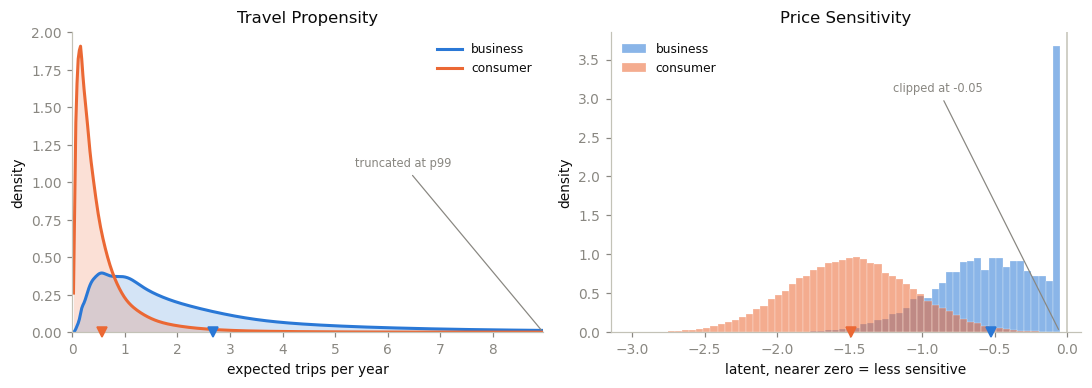

In [4]:
# Plot: Travel Propensity & Price Sensitivity
fig, axes = plt.subplots(1, 2, figsize = (10, 3.6))
SEGMENTS = [(True, 'business', ACCENT), (False, 'consumer', ACCENT2)]

# Travel Propensity
prop_years = accounts['travel_propensity'] * 12
q99 = prop_years.quantile(0.99)
x_grid = np.linspace(0.02, q99, 400)

for is_biz, label, color in SEGMENTS:
    vals = prop_years[accounts['is_business'] == is_biz]
    density = gaussian_kde(np.log(vals))(np.log(x_grid)) / x_grid
    axes[0].fill_between(x_grid, density, color = color, alpha = 0.20, linewidth = 0)
    axes[0].plot(x_grid, density, color = color, linewidth = 2, label = label)
    axes[0].plot(vals.mean(), 0, marker = 'v', color = color, markersize = 7, clip_on = False, zorder = 5)

axes[0].set_title('Travel Propensity')
axes[0].set_xlabel('expected trips per year')
axes[0].set_ylabel('density')
axes[0].set_xlim(0, q99)
axes[0].set_ylim(bottom = 0)
axes[0].legend(frameon = False, fontsize = 8, loc = 'upper right')
axes[0].annotate(
    'truncated at p99', xy = (q99, 0), xycoords = ('data', 'axes fraction'),
    xytext = (0.60, 0.55), textcoords = 'axes fraction',
    fontsize = 7.5, color = MUTED, ha = 'left',
    arrowprops = dict(arrowstyle = '-', color = MUTED, lw = 0.8)
)

# Price Sensitivity
for is_biz, label, color in SEGMENTS:
    vals = accounts.loc[accounts['is_business'] == is_biz, 'price_sensitivity']
    axes[1].hist(
        vals, bins = 60, range = (-3.0, -0.05), density = True, color = color,
        alpha = 0.55, edgecolor = SURFACE, linewidth = 0.3, label = label
    )
    axes[1].plot(vals.mean(), 0, marker = 'v', color = color, markersize = 7, clip_on = False, zorder = 5)

axes[1].axvline(0, color = BASELINE, linewidth = 1)
axes[1].set_title('Price Sensitivity')
axes[1].set_xlabel('latent, nearer zero = less sensitive')
axes[1].set_ylabel('density')
axes[1].legend(frameon = False, fontsize = 8, loc = 'upper left')
axes[1].annotate(
    'clipped at -0.05', xy = (-0.05, 0), xycoords = ('data', 'axes fraction'),
    xytext = (0.60, 0.80), textcoords = 'axes fraction',
    fontsize = 7.5, color = MUTED, ha = 'left',
    arrowprops = dict(arrowstyle = '-', color = MUTED, lw = 0.8)
)

plt.tight_layout()
plt.show()


## 2 · Macroeconomic Trajectory

**Purpose:** Builds a shared economic cycle that scales every account's trip volume by the same monthly draw, so account outcomes are correlated and the later Monte Carlo simulation reports a realistic revenue spread instead of overstated confidence.

**Design Notes:**

1. AR(1) index for economic expansion and contraction, converted to a travel-volume multiplier
  - phi sets persistence; gamma sets how strongly the economy moves travel volume
2. Seasonality: data-derived, not assumed
  - Source: U.S. Department of Commerce, International Trade Administration, I-92 program ([trade.gov/us-international-air-travel-statistics-i-92-data](https://www.trade.gov/us-international-air-travel-statistics-i-92-data))
  - Population: U.S. Citizen Originating passengers
  - Years: 2019, 2022-2025 (2020-2021 excluded: COVID collapse/recovery; 2026 excluded: partial year)
  - Regions: Caribbean, South America, Europe, Central America, Africa, Asia, Oceania, Mideast
  - Canada & Mexico excluded: international roaming does not apply to either

**Real-World Estimation:**

1. Unlike travel_propensity and price_sensitivity, the macro index is an aggregate signal, not a per-account trait, so it's directly computable from historical company-wide data, not inferred indirectly
  - Take total roaming activity (trips, minutes, sessions) across the whole customer base each month
  - Remove the known seasonal component (the same I-92-derived pattern used above) to leave a deseasonalized residual
  - That residual is the empirical analog of macro_index
2. phi and sigma would be fit to that residual series, not assumed
  - phi estimated from the residual's month-to-month autocorrelation
  - sigma estimated from the residual's volatility after accounting for that persistence
3. gamma would be estimated by regressing the residual travel volume against the fitted macro signal itself, the same elasticity-style approach used for price
4. External indicators (GDP growth, consumer confidence, exchange rates, airline industry passenger volumes, corporate travel spend) could supplement or replace a purely internal deseasonalized signal, particularly for forecasting beyond the observed history

**Observations:**

1. Macro index (this run) ranges from -0.76 to +0.55, reflecting the AR(1) random walk's specific realized path
2. Travel multiplier swings over 3x across the panel, from 0.49 to 1.52
3. Both panels move together, confirming the multiplier tracks the underlying macro index as designed
4. Seasonality alone ranges 0.70 (Feb) to 1.37 (Jun), matching the empirical I-92 derivation


In [5]:
# Build Macro Path
i92 = pd.read_csv('reference/us_i92_air_travel.csv')
i92_clean = i92[~i92['Year'].isin([2020, 2021, 2026])]
SEASONALITY_INDEX = (
    i92_clean.groupby('Month Number')['U.S. Citizen Originating'].mean()
    .pipe(lambda s: s / s.mean()).to_numpy()
)
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
display(pd.DataFrame({'seasonality index': np.round(SEASONALITY_INDEX, 3)}, index=MONTH_NAMES))

def make_macro(n_months, rng, phi = 0.85, sigma = 0.35, gamma = 0.55):
    idx = np.zeros(n_months)
    for t in range(1, n_months):
        idx[t] = phi * idx[t - 1] + rng.normal(0, sigma)

    month = np.arange(n_months)
    seasonality = SEASONALITY_INDEX[month % 12]

    return pd.DataFrame({
        'month': month,
        'macro_index': idx,
        'seasonality': seasonality,
        'travel_multiplier': np.exp(gamma * idx) * seasonality,
    })

macro = make_macro(N_MONTHS, RNG)
macro.head()


,seasonality index
Jan,0.700
Feb,0.706
Mar,0.986
Apr,0.933
May,1.117
Jun,1.373
Jul,1.289
Aug,1.065
Sep,0.975
Oct,0.911


,month,macro_index,seasonality,travel_multiplier
0,0,0.000000,0.699788,0.699788
1,1,-0.035610,0.706191,0.692494
2,2,-0.475274,0.985865,0.759089
3,3,-0.500878,0.932844,0.708220
4,4,-0.701075,1.117243,0.759780


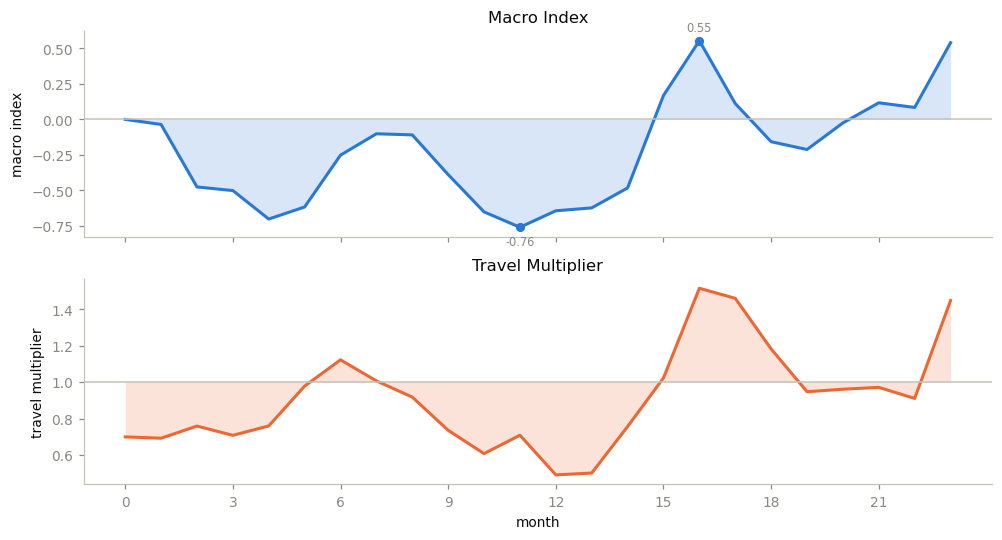

In [6]:
# Plot: Macroeconomic Trajectory
fig, axes = plt.subplots(
    2, 1, figsize = (9, 4.8), sharex = True,
    gridspec_kw = {'height_ratios': [1, 1]}, layout = 'constrained',
)

# Macro Index
axes[0].fill_between(macro['month'], 0, macro['macro_index'], color = ACCENT, alpha = 0.18, linewidth = 0)
axes[0].plot(macro['month'], macro['macro_index'], color = ACCENT, linewidth = 2)
axes[0].axhline(0, color = BASELINE, linewidth = 1)
axes[0].set_ylabel('macro index')
axes[0].set_title('Macro Index')

peak = macro.loc[macro['macro_index'].idxmax()]
trough = macro.loc[macro['macro_index'].idxmin()]

axes[0].plot(
    [peak['month'], trough['month']], [peak['macro_index'], trough['macro_index']],
    marker = 'o', linestyle = 'none', color = ACCENT, markersize = 5, zorder = 5
)

axes[0].annotate(
    f"{peak['macro_index']:.2f}", xy = (peak['month'], peak['macro_index']),
    xytext = (0, 6), textcoords = 'offset points', fontsize = 7.5, color = MUTED,
    ha = 'center', annotation_clip = False
)

axes[0].annotate(
    f"{trough['macro_index']:.2f}", xy = (trough['month'], trough['macro_index']),
    xytext = (0, -12), textcoords = 'offset points', fontsize = 7.5, color = MUTED,
    ha = 'center', annotation_clip = False
)

# Travel Multiplier
axes[1].fill_between(
    macro['month'], 1.0, macro['travel_multiplier'], color = ACCENT2, 
    alpha = 0.18, linewidth = 0
)
axes[1].plot(macro['month'], macro['travel_multiplier'], color = ACCENT2, linewidth = 2)
axes[1].axhline(1.0, color = BASELINE, linewidth = 1)
axes[1].set_ylabel('travel multiplier')
axes[1].set_xlabel('month')
axes[1].set_title('Travel Multiplier')
axes[1].set_xticks(range(0, N_MONTHS, 3))

plt.show()


## 3 · Trips

**Purpose:** Draws each account's trips for the month via a Poisson process, attaching a destination, party size, and duration to each one.

**Design Notes:**

1. Regions match the I-92 taxonomy from §2: Europe, Caribbean, Asia, South America, Central America, Mideast, Oceania, Africa
  - Canada and Mexico excluded, consistent with §2: international roaming does not apply to either
2. Destination proxies substitute ease, not just geography
  - Mature eSIM coverage → a real alternative to the pass
  - Caps how far price can move, regardless of elasticity
3. SUBSTITUTE_EASE: higher = easier to substitute the pass with eSIM, local SIM, or Wi-Fi
4. Party composition: business trips are usually solo; leisure trips bring the household
5. Duration: business trips shorter and tighter; leisure longer and more variable

**Real-World Estimation:**

1. Trip occurrence, destination, and duration are directly observable in production, unlike travel_propensity or price_sensitivity
  - A trip would be constructed by clustering an account's foreign-network registration events (roaming CDRs) into episodes, not modeled as a latent Poisson draw
  - Destination region comes straight from the visited network's country code in the roaming record
  - Duration is the span between the first and last foreign-network event in that episode
2. Party size (lines_traveling) would be inferred, not directly recorded
  - Constructed by matching which of an account's other lines show foreign-network activity in the same date range
  - No single field marks "traveling together"; it's a derived grouping, not a raw field
3. substitute_ease is the one latent element in this section, similar in spirit to price_sensitivity
  - Not directly observable: no field records how easy it was to avoid buying a pass
  - Could be proxied from the pass attach rate by destination region: regions where fewer roaming-eligible trips result in a purchase suggest easier substitution
  - Or sourced externally: eSIM/local SIM market coverage data, roaming agreement quality by country

**Observations:**

1. 94,579 trips generated across 29,406 of the 50,000 accounts
2. Region mix: Europe 30%, Caribbean 18%, Asia 16%, South America 10%, Central America 8%, Mideast 6%, Africa 6%, Oceania 6%
3. Party size dominated by solo travelers (76%); only 1% travel in parties of 5
4. Business trips average 4.2 days; consumer trips average 7.2 days, matching the shorter/tighter design intent

In [7]:
# Generate Trips
REGIONS = ['europe', 'caribbean', 'asia', 'south_america', 'central_america', 'mideast', 'oceania', 'africa']
REGION_P = [0.30, 0.18, 0.16, 0.10, 0.08, 0.06, 0.06, 0.06]
SUBSTITUTE_EASE = {
    'europe': 0.85, 'caribbean': 0.45, 'asia': 0.75, 'south_america': 0.55,
    'central_america': 0.45, 'mideast': 0.55, 'oceania': 0.65, 'africa': 0.35,
}

def make_trips(accounts, macro, rng):
    
    prop = accounts['travel_propensity'].to_numpy()[:, None]
    mult = macro['travel_multiplier'].to_numpy()[None, :]

    counts = rng.poisson(prop * mult)
    acct_idx, month_idx = np.nonzero(counts)
    reps = counts[acct_idx, month_idx]

    account_id = np.repeat(accounts['account_id'].to_numpy()[acct_idx], reps)
    month = np.repeat(month_idx, reps)
    n_trips = len(account_id)

    lines_available = accounts.set_index('account_id').loc[account_id, 'lines_on_account'].to_numpy()
    is_business = accounts.set_index('account_id').loc[account_id, 'is_business'].to_numpy()

    solo_p = np.where(is_business, 0.82, 0.32)
    solo = rng.random(n_trips) < solo_p
    lines_traveling = np.where(
        solo, 1, 1 + rng.binomial(np.maximum(lines_available - 1, 0), 0.75),
    )

    region = rng.choice(REGIONS, size = n_trips, p = REGION_P)

    days = np.where(
        is_business,
        rng.lognormal(1.35, 0.40, size = n_trips),
        rng.lognormal(1.80, 0.60, size = n_trips),
    )
    
    days_traveled = np.clip(np.round(days), 1, 30).astype(int)

    return pd.DataFrame({
        'trip_id': np.arange(n_trips),
        'account_id': account_id,
        'month': month,
        'region': region,
        'lines_traveling': lines_traveling.astype(int),
        'days_traveled': days_traveled,
        'substitute_ease': [SUBSTITUTE_EASE[r] for r in region],
    })

trips = make_trips(accounts, macro, RNG)
print(f'{len(trips):,} Trips Across {trips.account_id.nunique():,} Accounts')
trips.head()


94,579 Trips Across 29,406 Accounts


,trip_id,account_id,month,region,lines_traveling,days_traveled,substitute_ease
0,0,1,0,south_america,1,2,0.55
1,1,1,5,caribbean,1,3,0.45
2,2,1,5,africa,1,4,0.35
3,3,1,8,africa,1,4,0.35
4,4,1,8,africa,3,4,0.35


## 4 · Effective Price

**Purpose:** Assigns each trip the price it actually faced, engineered with deliberate variation and confounding, so a price response can be estimated at all and the modeling notebook has a real confounding problem to demonstrate handling.

**Design Notes:**

1. Variation generated three ways
  - Market test: Europe/Asia-Pacific regions (Asia + Oceania) carry a higher rate during months 8-15
  - Promotional window: a discount in the shoulder season (months 4, 5, 16, 17)
  - Residual drift: a small share of remaining trips get random variation, so it is not purely two clean blocks
2. ~1/3 of trips face a non-standard rate
3. Multiplier deliberately correlated with region and period, not random: a naive fit would attribute region/traveler differences to price

**Observations:**

1. 66.9% of trips face the standard rate; the remaining 33.1% split across four off-standard levels
2. Discounted trips (0.90-0.95x): 15.6% combined
3. Premium trips (1.10-1.20x): 17.5% combined, roughly balanced against the discounted share

In [8]:
# Assign Price
def assign_price(trips, rng):
    
    n = len(trips)
    mult = np.ones(n)

    in_test = trips['region'].isin(['europe', 'asia', 'oceania']).to_numpy() & trips['month'].between(8, 15).to_numpy()
    mult = np.where(in_test, rng.choice([1.10, 1.20], size = n, p = [0.5, 0.5]), mult)

    in_promo = trips['month'].isin([4, 5, 16, 17]).to_numpy() & (rng.random(n) < 0.55)
    mult = np.where(in_promo & ~in_test, rng.choice([0.90, 0.95], size = n, p = [0.6, 0.4]), mult)

    drift = (rng.random(n) < 0.10)
    mult = np.where(drift & ~in_test & ~in_promo, rng.choice([0.95, 1.10], size = n), mult)

    out = trips.copy()
    out['price_multiplier'] = mult
    out['price_first_line'] = PRICE_FIRST_LINE * mult
    out['price_addl_line'] = PRICE_ADDL_LINE * mult
    return out


trips = assign_price(trips, RNG)
display(
    trips['price_multiplier'].value_counts(normalize = True).sort_index().round(3)
        .to_frame('share of trips').rename_axis(None)
)


,share of trips
0.90,0.071
0.95,0.085
1.00,0.669
1.10,0.106
1.20,0.069


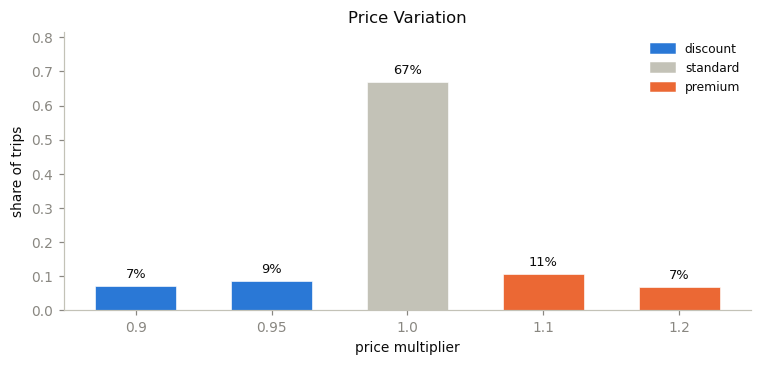

In [9]:
# Plot: Price Variation
price_share = trips['price_multiplier'].value_counts(normalize = True).sort_index()
CATEGORY_COLOR = {0.90: ACCENT, 0.95: ACCENT, 1.00: BASELINE, 1.10: ACCENT2, 1.20: ACCENT2}
colors = [CATEGORY_COLOR[m] for m in price_share.index]

fig, ax = plt.subplots(figsize = (7, 3.4))
bars = ax.bar(
    price_share.index.astype(str), price_share.values, width = 0.6,
    color = colors, edgecolor = SURFACE, linewidth = 0.4
)

for b, v in zip(bars, price_share.values):
    ax.text(
        b.get_x() + b.get_width() / 2, v + 0.015, f'{v:.0%}',
        ha = 'center', va = 'bottom', fontsize = 8.5, color = INK
    )

handles = [
    Patch(color = ACCENT, label = 'discount'),
    Patch(color = BASELINE, label = 'standard'),
    Patch(color = ACCENT2, label = 'premium'),
]
ax.legend(handles = handles, frameon = False, fontsize = 8, loc = 'upper right')

ax.set_ylim(0, price_share.max() * 1.22)
ax.set_xlabel('price multiplier')
ax.set_ylabel('share of trips')
ax.set_title('Price Variation')
plt.tight_layout()
plt.show()


## 5 · Behavioral State

**Purpose:** For every trip, this section decides what the account actually did in response to the price it faced: one of four states (full, partial, substitutes, leaves).

**Design Notes:**

1. Multinomial logit over four states; full is the reference
2. Utilities move with sensitivity × log(price multiplier)
  - Price up → probability shifts toward leaving, substituting, partial coverage
  - Price down → probability shifts back toward full coverage
3. Relief term: 0 for solo travelers, rising with party size as the per-head rate falls
4. Two structural choices
  - Leaving is rare (large negative intercept) but expensive: a class-imbalance problem; untreated model under-predicts it, and the simulation understates the downside
  - Substitution scales with substitute_ease: a good alternative → lower price ceiling, regardless of sensitivity
5. There is no 'increases' state. The pass bills per 24-hour period of foreign-network connection, so an account cannot buy more days than it travels; a price cut shows up as fewer partial / substitute / leave outcomes, not as extra coverage
6. Chart: red shades for the loss states (leaves, substitutes, partial), gray for full coverage

**Real-World Estimation:**

1. State itself is not directly observable in production; it would first need to be reconstructed from the observables covered in Part 2 (coverage ratio, days bought, lines active) into the three levels null / partial / full, not read from a truth column
2. Once reconstructed, the utility coefficients here (state intercepts, the sensitivity x log-price slope, the party-size relief term, substitution's dependence on substitute_ease) would be estimated by fitting a multinomial logit to real trips, not hand-set
  - This is the task performed downstream in the state-modeling notebook
3. The structural choices baked in here (leaving as a rare class, substitution scaling with substitute ease) would need to emerge as findings from the fitted model, not assumptions made in advance

**Observations:**

1. full coverage dominates at 78.0% of trips
2. partial (11.8%) and substitutes (9.9%) are the two largest response states
3. leaves is rare by design, at 0.3% of trips


In [10]:
# Draw Behavioral State
STATES = ['leaves', 'substitutes', 'partial', 'full']

def state_probabilities(trips, accounts):

    a = accounts.set_index('account_id').loc[trips['account_id'].to_numpy()]
    sens = a['price_sensitivity'].to_numpy()
    is_business = a['is_business'].to_numpy()
    tenure = a['tenure_months'].to_numpy()

    logp = np.log(trips['price_multiplier'].to_numpy())
    ease = trips['substitute_ease'].to_numpy()
    party = trips['lines_traveling'].to_numpy()

    eff_price_relief = 1.0 - (PRICE_FIRST_LINE + PRICE_ADDL_LINE * (party - 1)) / (PRICE_FIRST_LINE * party)

    u_full = np.zeros(len(trips))

    u_leaves = (
        -5.20 + (-sens) * 1.10 * logp -
        0.55 * is_business -
        0.004 * tenure
    )

    u_substitutes = (
        -2.60 + (-sens) * 1.85 * logp +
        1.30 * ease -
        0.70 * is_business
    )

    u_partial = (
        -1.90 + (-sens) * 1.55 * logp +
        0.45 * ease -
        0.40 * is_business -
        0.80 * eff_price_relief
    )

    U = np.column_stack([u_leaves, u_substitutes, u_partial, u_full])
    U = U - U.max(axis = 1, keepdims = True)
    P = np.exp(U)

    return P / P.sum(axis = 1, keepdims = True)

P = state_probabilities(trips, accounts)
drawn = (P.cumsum(axis = 1) < RNG.random((len(P), 1))).sum(axis = 1)
trips['state'] = [STATES[i] for i in drawn]

STATE_ORDER = ['leaves', 'substitutes', 'partial', 'full']
display(
    trips['state'].value_counts(normalize = True).round(4).reindex(STATE_ORDER)
        .to_frame('share of trips').rename_axis(None)
)

,share of trips
leaves,0.0026
substitutes,0.0985
partial,0.1184
full,0.7804


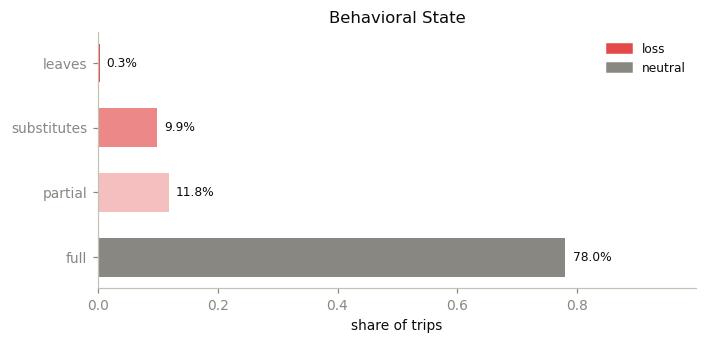

In [11]:
# Plot: Behavioral State
STATE_ORDER = ['leaves', 'substitutes', 'partial', 'full']
STATE_STYLE = {
    'leaves':      dict(color = RED, alpha = 1.00),
    'substitutes': dict(color = RED, alpha = 0.65),
    'partial':     dict(color = RED, alpha = 0.35),
    'full':        dict(color = MUTED, alpha = 1.00),
}

state_share = trips['state'].value_counts(normalize = True).reindex(STATE_ORDER)

fig, ax = plt.subplots(figsize = (6.5, 3.2))
y = np.arange(len(STATE_ORDER))

for yi, s in zip(y, STATE_ORDER):
    ax.barh(yi, state_share[s], height = 0.6, **STATE_STYLE[s])
    ax.text(
        state_share[s] + 0.012, yi, f'{state_share[s]:.1%}',
        va = 'center', fontsize = 8, color = INK
    )

ax.set_yticks(y)
ax.set_yticklabels(STATE_ORDER)
ax.invert_yaxis()
ax.set_xlim(0, state_share.max() * 1.28)
ax.set_xlabel('share of trips')
ax.set_title('Behavioral State')

handles = [
    Patch(color = RED, label = 'loss'),
    Patch(color = MUTED, label = 'neutral'),
]
ax.legend(handles = handles, frameon = False, fontsize = 8, loc = 'upper right')

plt.tight_layout()
plt.show()

## 6 · Magnitude

**Purpose:** Sizes the one price-responsive state (partial), so a bigger price move produces a deeper reduction in coverage, not just more people reducing.

**Design Notes:**

1. Three states are self-sizing: full ≈ complete coverage; substitutes/leaves = zero
2. The price-responsive state (partial) can move on both day count and line count (a household can share one line)
3. Full is not exactly complete coverage
  - Incidental shortfall: late arrival, hotel wifi, forgot to activate
  - Deliberate: without it, the reduce-vs-unchanged boundary would be trivially separable
  - Shortfall is mostly one day, occasionally two
4. Partial: day-coverage share drawn from a Beta distribution whose mean shifts down as price rises; some of the reduction also comes out of lines instead of days

**Real-World Estimation:**

1. The Beta-distribution parameters governing partial-coverage depth would be fit to real coverage ratios (days_bought / days_traveled) conditional on price and segment, not assumed
  - This is the magnitude-modeling task performed downstream in notebook 02
2. The incidental-shortfall floor (the small, universal undershoot that keeps partial/full from being trivially separable) would need to be estimated from full-labeled trips specifically
3. Whether a reduction or increase comes out of days or lines would be estimated from the joint distribution of both, not assumed as a fixed split

**Observations:**

1. Full trips buy 5.27 of 5.40 average travelled days (97.6% coverage; the gap is the incidental shortfall)
2. Partial trips buy 3.03 of 5.65 average travelled days (53.6% coverage), and lines drop from 1.36 to 1.27
3. The no-coverage states (substitutes, leaves) correctly show zero days bought and zero lines active


In [12]:
# Compute Magnitude
def make_magnitudes(trips, accounts, rng):

    n = len(trips)
    state = trips['state'].to_numpy()
    days_t = trips['days_traveled'].to_numpy()
    lines_t = trips['lines_traveling'].to_numpy()
    logp = np.log(trips['price_multiplier'].to_numpy())

    days_bought = days_t.copy().astype(float)
    lines_active = lines_t.copy().astype(float)

    # Partial: day-coverage share from a Beta whose mean falls as price rises;
    # some of the reduction comes out of lines instead of days.
    m = state == 'partial'
    mean_share = np.clip(0.55 - 1.20 * logp[m], 0.10, 0.85)
    conc = 6.0
    share = rng.beta(mean_share * conc, (1 - mean_share) * conc)
    days_bought[m] = np.maximum(np.round(days_t[m] * share), 1)
    drop_line = (rng.random(m.sum()) < 0.35) & (lines_t[m] > 1)
    la = lines_active[m]
    la[drop_line] = np.maximum(np.round(la[drop_line] * rng.uniform(0.4, 0.8, drop_line.sum())), 1)
    lines_active[m] = la

    # Full: near-complete coverage, with a small incidental shortfall that keeps
    # the partial / full boundary from being trivially separable.
    m = state == 'full'
    incidental = (rng.random(m.sum()) < 0.12) & (days_t[m] >= 3)
    db = days_bought[m]
    lost = np.where(rng.random(incidental.sum()) < 0.20, 2, 1)
    db[incidental] = np.maximum(db[incidental] - lost, 1)
    days_bought[m] = db

    # No coverage
    m = np.isin(state, ['substitutes', 'leaves'])
    days_bought[m] = 0
    lines_active[m] = 0

    out = trips.copy()
    out['days_bought'] = days_bought.astype(int)
    out['lines_active'] = lines_active.astype(int)

    return out

trips = make_magnitudes(trips, accounts, RNG)
STATE_ORDER = ['leaves', 'substitutes', 'partial', 'full']
(trips.groupby('state')[['days_traveled', 'days_bought', 'lines_traveling', 'lines_active']]
    .mean().round(2).reindex(STATE_ORDER).rename_axis(None))

,days_traveled,days_bought,lines_traveling,lines_active
leaves,5.65,0.00,1.41,0.00
substitutes,6.00,0.00,1.45,0.00
partial,5.65,3.03,1.36,1.27
full,5.40,5.27,1.41,1.41


## 7 · Revenue

**Purpose:** Applies the pricing identity to what was actually bought, and books a lost account as the value of the whole relationship rather than a single zero-revenue trip.

**Design Notes:**

1. Pricing identity applied to what was actually bought:

```
revenue = (price_first_line + price_addl_line × (lines_active − 1)) × days_bought
```

2. leaves recorded separately, not as zero-revenue
  - Account-level loss attached here, left for the revenue model to weight

**Observations:**

1. Total pass revenue: 5,204,668 across the 24-month panel
2. 249 accounts lost (state = leaves)
3. full coverage carries almost all revenue (4.81M, 92.4% of the total), at 65.18 average per trip
4. partial trips still generate 393,623, at a lower average of 35.14 per trip


In [13]:
# Compute Revenue
def compute_revenue(trips):
    
    out = trips.copy()
    active = out['lines_active'].to_numpy()
    rev = np.where(
        active > 0,
        (out['price_first_line'].to_numpy() + out['price_addl_line'].to_numpy() * (active - 1))
        * out['days_bought'].to_numpy(),
        0.0,
    )
    out['pass_revenue'] = rev
    out['account_lost'] = (out['state'] == 'leaves').astype(int)
    
    return out

trips = compute_revenue(trips)

print(f'Total Pass Revenue: ${trips.pass_revenue.sum():,.0f}')
print(f'Accounts Lost:      {trips.account_lost.sum():,}')

STATE_ORDER = ['leaves', 'substitutes', 'partial', 'full']
trips.groupby('state')['pass_revenue'].agg(['count', 'sum', 'mean']).round(2).reindex(STATE_ORDER).rename_axis(None)


Total Pass Revenue: $5,204,668
Accounts Lost:      249


,count,sum,mean
leaves,249,0.0,0.00
substitutes,9317,0.0,0.00
partial,11202,393623.0,35.14
full,73811,4811045.5,65.18


## 8 · Sanity Checks

**Purpose:** Confirms the generator's parameters produced domain-plausible behavior, since anything downstream inherits whatever it got wrong.

**Design Notes:**

1. Any failure below → parameters are wrong, nothing downstream is worth fitting
  - Revenue per trip moves coherently with price; raw and composition-adjusted views agree
  - Business accounts measurably less sensitive than consumer accounts
  - Substitution more common where the alternative is easier
  - Trip volume tracks the macro index
2. Check 1 passes only if raw and within-segment-adjusted revenue tell the same story; a disagreement would mean the pattern is composition, not response

**Observations:**

1. Revenue per trip rises with price on both the raw (51.45 → 57.35) and within-segment-adjusted (54.05 → 60.30) views, confirming a real response rather than composition
2. No-purchase rate rises with price for both segments, and consistently higher for consumer than business (e.g., 22.3% vs 9.4% at 1.20x)
3. Substitution rate ranges from 6.7% (Africa) to 12.6% (Europe), tracking substitute_ease as designed
4. Trip volume correlates with the macro index at 0.758, confirming the shared macro path drives volume


In [14]:
# Run Sanity Checks
chk = trips.merge(accounts[['account_id', 'is_business']], on = 'account_id')

print('1 · Revenue per Trip by Price Multiplier')
raw = chk.groupby('price_multiplier')['pass_revenue'].mean().round(2)
adj = (
    chk.groupby(['is_business', 'region', 'price_multiplier'])['pass_revenue'].mean()
        .groupby('price_multiplier').mean().round(2)
)
display(pd.DataFrame({'raw': raw, 'within segment x region': adj}).rename_axis(None))

print('2 · Share of Trips Buying Nothing by Price & Segment')
chk['no_purchase'] = chk['days_bought'].eq(0)
no_purchase_table = chk.pivot_table(
    index = 'price_multiplier', columns = 'is_business',
    values = 'no_purchase', aggfunc = 'mean').round(3)
no_purchase_table.columns = no_purchase_table.columns.map({False: 'consumer', True: 'business'})
display(no_purchase_table.rename_axis(None).rename_axis(None, axis = 1))

print('3 · Substitution Rate by Region')
display(
    chk.assign(sub = chk.state.eq('substitutes')).groupby('region')['sub'].mean().round(3)
        .to_frame('substitution rate').rename_axis(None)
)

vol = trips.groupby('month').size().rename('trips').reset_index().merge(macro, on = 'month')
print(f'4 · Correlation of Monthly Trip Volume with Macro Index: {round(vol['trips'].corr(vol['macro_index']), 3)}')


1 · Revenue per Trip by Price Multiplier


,raw,within segment x region
0.90,51.45,54.05
0.95,53.28,55.71
1.00,55.19,57.92
1.10,56.34,61.29
1.20,57.35,60.30


2 · Share of Trips Buying Nothing by Price & Segment


,consumer,business
0.90,0.110,0.074
0.95,0.120,0.070
1.00,0.127,0.072
1.10,0.173,0.086
1.20,0.223,0.094


3 · Substitution Rate by Region


,substitution rate
africa,0.067
asia,0.111
caribbean,0.074
central_america,0.078
europe,0.126
mideast,0.086
oceania,0.099
south_america,0.081


4 · Correlation of Monthly Trip Volume with Macro Index: 0.758


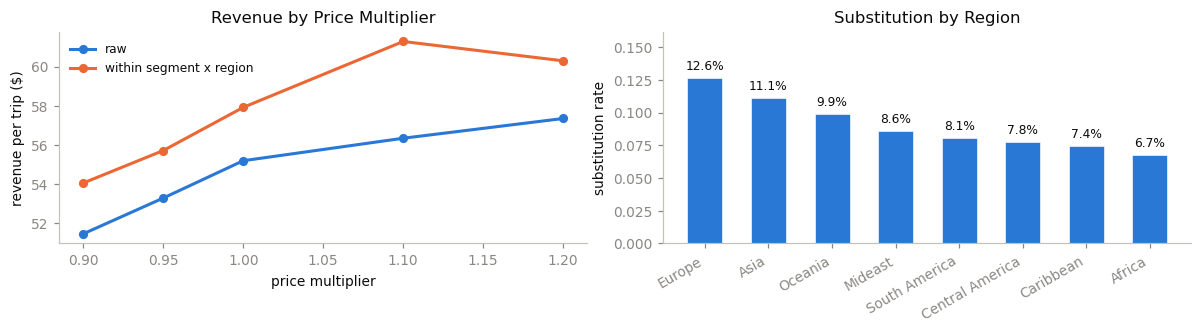

In [15]:
# Plot: Sanity Checks
fig, axes = plt.subplots(1, 2, figsize = (11, 3.1))

comp = pd.DataFrame({'raw': raw, 'within segment x region': adj})
axes[0].plot(comp.index, comp['raw'], color = ACCENT, linewidth = 2, marker = 'o', ms = 5, label = 'raw')
axes[0].plot(
    comp.index, comp['within segment x region'], color = ACCENT2, linewidth = 2,
    marker = 'o', ms = 5, label = 'within segment x region'
)
axes[0].set_xlabel('price multiplier')
axes[0].set_ylabel('revenue per trip ($)')
axes[0].set_title('Revenue by Price Multiplier')
axes[0].legend(frameon = False, fontsize = 8)

sub_by_region = (
    chk.assign(sub = chk.state.eq('substitutes'))
        .groupby('region')['sub'].mean().sort_values(ascending = False)
)

region_labels = [r.replace('_', ' ').title() for r in sub_by_region.index]

bars = axes[1].bar(
    region_labels, sub_by_region.values, width = 0.55,
    color = ACCENT, edgecolor = SURFACE, linewidth = 0.4
)

for b, v in zip(bars, sub_by_region.values):
    axes[1].text(
        b.get_x() + b.get_width() / 2, v + 0.004, f'{v:.1%}',
        ha = 'center', va = 'bottom', fontsize = 8, color = INK
    )
    
axes[1].set_ylim(0, sub_by_region.max() * 1.28)
axes[1].set_ylabel('substitution rate')
axes[1].set_title('Substitution by Region')
axes[1].tick_params(axis = 'x', labelrotation = 30)

for tick in axes[1].get_xticklabels():
    tick.set_ha('right')

plt.tight_layout()
plt.show()


## 9 · Ground Truth

**Purpose:** Exports the true latent sensitivity to a separate file, kept out of the modeling data, so later notebooks can be scored on whether they actually recover the signal rather than just how well they fit.

**Design Notes:**

1. Signal provably present but not recovered → the model is the problem, not the data
2. Model-facing tables exclude the latent traits (model_accounts drops price_sensitivity, travel_propensity)
3. Parquet preferred (smaller, keeps dtypes); falls back to CSV if pyarrow/fastparquet are not installed

**Observations:**

1. Four tables written: accounts, macro, trips, ground_truth
2. ground_truth.parquet is 1.32 MB, the second-largest of the four
3. accounts.parquet (model-facing, latent traits dropped) is 0.39 MB


In [16]:
# Export Ground Truth
ground_truth = accounts[['account_id', 'price_sensitivity', 'travel_propensity']].copy()
ground_truth['sensitivity_decile'] = pd.qcut(ground_truth['price_sensitivity'], 10, labels = False)

model_accounts = accounts.drop(columns = ['price_sensitivity', 'travel_propensity'])

try:
    import pyarrow
    FMT = 'parquet'
    
except ImportError:
    
    try:
        import fastparquet
        FMT = 'parquet'
        
    except ImportError:
        FMT = 'csv'
        print('pyarrow/fastparquet not found, writing CSV instead.')
        print('For smaller files: pip install pyarrow\n')


def save(df, name):
    
    path = DATA / f'{name}.{FMT}'
    df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
    
    return path


paths = [
    save(df, name) for df, name in [(model_accounts, 'accounts'), (macro, 'macro'), (trips, 'trips'), (ground_truth, 'ground_truth')]
]

print(f'Written to: {DATA.resolve()}')
display(pd.DataFrame({'size (MB)': [round(p.stat().st_size / 1e6, 2) for p in paths]},
                      index = [p.name for p in paths]).rename_axis(None))
    

Written to: /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/data/synthetic


,size (MB)
accounts.parquet,0.39
macro.parquet,0.00
trips.parquet,1.39
ground_truth.parquet,1.32


---
# Part 2 · Validating the Synthetic Data

1. Confirm the generated panel behaves like a plausible telecom population before fitting anything
2. Settle the one decision modeling depends on: how to reconstruct the five behavioral states from observables
3. Not exploratory in the usual sense: the generating process is known, and every check either validates the generator or produces a number the labeling rule needs
4. Three questions:
  - Does the panel look real? Marginals, ratios, revenue concentration in realistic ranges
  - Is the label boundary readable from the data? Bimodal coverage ratio → threshold reads off the shape
  - Is there enough price variation to estimate a response, per segment? A segment with no price change can't have its sensitivity estimated
5. Failure in (1) → fix parameters in Part 1; failure in (3) → change the price-variation design; neither is recoverable downstream
6. Reuses Part 1's in-memory objects; accounts is rebound to model_accounts (latent traits dropped) to match what downstream notebooks load from disk


In [17]:
# Reuse Part 1 Objects
accounts = model_accounts
trips = trips.merge(accounts, on='account_id', how='left')

print(f'{len(accounts):,} accounts · {len(trips):,} trips · {macro.month.nunique()} months')


50,000 accounts · 94,579 trips · 24 months


---
## 1 · Panel Realism

**Purpose:** Confirms the synthetic population looks like a real travel population before anything is fitted to it, checking coverage, segment differences, revenue concentration, and macro sensitivity.

### 1.1 Coverage & Shape

**Design Notes:**

1. Population should not be uniformly active
2. Real travel is concentrated: most accounts never travel internationally in a year; a small group travels constantly
3. If everyone travels a similar amount, segmentation later has nothing to separate

**Expected Characteristics:**

- Large share of accounts with zero trips: international travel is a minority behavior
- Trip duration right-skewed; business trips short, leisure long-tailed
- Party size dominated by 1, with a meaningful household-travel tail (where the $5 additional-line economics live)
- Symmetric or flat duration/party size → generator parameters need adjusting

**Observations:**

1. 58.8% of accounts travelled at all (29,406 of 50,000); the rest are dormant over the 24-month window
2. Travelling accounts took a median of 2 trips, with a p95 of 10, confirming a small group travels far more than typical
3. Trip duration and party size are both right-skewed in the plots, matching expectation


,value
accounts,"50,000"
accounts that travelled,"29,406"
share that travelled,58.8%
trips total,"94,579"
trips per travelling account (median),2
trips per travelling account (p95),10
months,24


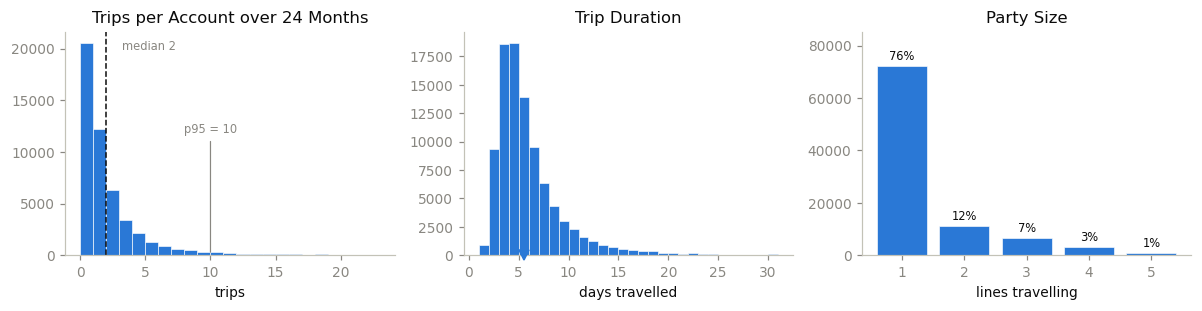

In [18]:
# Check Coverage & Shape
trips_per_account = trips.groupby('account_id').size()
all_accounts = accounts.set_index('account_id').index
trip_counts = trips_per_account.reindex(all_accounts, fill_value = 0)

n_months = macro.month.nunique()
summary = pd.Series({
    'accounts': len(accounts),
    'accounts that travelled': (trip_counts > 0).sum(),
    'share that travelled': (trip_counts > 0).mean(),
    'trips total': len(trips),
    'trips per travelling account (median)': trip_counts[trip_counts > 0].median(),
    'trips per travelling account (p95)': trip_counts[trip_counts > 0].quantile(0.95),
    'months': n_months,
})

ROW_FORMAT = ['{:,.0f}', '{:,.0f}', '{:.1%}', '{:,.0f}', '{:.0f}', '{:.0f}', '{:.0f}']

display(pd.DataFrame(
    {'value': [f.format(v) for f, v in zip(ROW_FORMAT, summary.values)]}, index = summary.index
))

fig, axes = plt.subplots(1, 3, figsize = (11, 2.9))

axes[0].hist(
    trip_counts, bins = range(0, int(trip_counts.quantile(0.995)) + 2),
    color = ACCENT, edgecolor = SURFACE, linewidth = 0.4
)

median_trips = trip_counts[trip_counts > 0].median()
p95_trips = trip_counts[trip_counts > 0].quantile(0.95)
axes[0].axvline(median_trips, color = INK, linewidth = 1, linestyle = '--')

axes[0].annotate(
    f'median {median_trips:.0f}', xy = (median_trips, axes[0].get_ylim()[1]),
    xytext = (median_trips + 1.2, axes[0].get_ylim()[1] * 0.92),
    fontsize = 7.5, color = MUTED
)

axes[0].annotate(
    f'p95 = {p95_trips:.0f}', xy = (p95_trips, 0),
    xytext = (p95_trips, axes[0].get_ylim()[1] * 0.55),
    fontsize = 7.5, color = MUTED, ha = 'center',
    arrowprops = dict(arrowstyle = '-', color = MUTED, lw = 0.8)
)

axes[0].set_title(f'Trips per Account over {n_months} Months')
axes[0].set_xlabel('trips')

axes[1].hist(
    trips['days_traveled'], bins = range(1, 32), color = ACCENT,
    edgecolor = SURFACE, linewidth = 0.4
)

axes[1].plot(
    trips['days_traveled'].mean(), 0, marker = 'v', color = ACCENT,
    markersize = 6, clip_on = False, zorder = 5
)

axes[1].set_title('Trip Duration')
axes[1].set_xlabel('days travelled')

party = trips['lines_traveling'].value_counts().sort_index()
party_total = party.sum()
bars = axes[2].bar(party.index, party.values, color = ACCENT, edgecolor = SURFACE, linewidth = 0.4)
for x, v in zip(party.index, party.values):
    axes[2].text(x, v + party_total * 0.012, f'{v / party_total:.0%}',
                 ha = 'center', va = 'bottom', fontsize = 7.5, color = INK)
axes[2].set_ylim(0, party.max() * 1.18)
axes[2].set_title('Party Size')
axes[2].set_xlabel('lines travelling')

plt.tight_layout()
plt.show()


### 1.2 Business & Consumer Differentiation

**Design Notes:**

1. Entire pricing argument rests on these two groups responding differently
2. Indistinguishable in raw data → model has nothing to find, segmentation is noise
3. Duration chart: two identity series, so categorical slots 1 and 2 (not accent-vs-muted)
4. State mix chart: same diverging color treatment as the state-mix chart in Part 1, for consistency

**Observations:**

1. Business trips are shorter (4.2 vs 7.2 days) and more often solo (85.7% vs 63.9%)
2. Business accounts travel far more often per account (5.62 vs 2.05 trips) but spend less per trip (41.34 vs 73.34)
3. Business accounts are worth more overall: 232.16 vs 150.11 revenue per account
4. Business no-purchase rate is lower (7.5% vs 13.6%), consistent with lower price sensitivity


Per Trip


,trips,accounts,avg_days,avg_party,solo_share,no_purchase_rate,avg_revenue
consumer,40469,19772,7.217,1.570,0.639,0.136,73.340
business,54110,9634,4.190,1.288,0.857,0.075,41.336


Per Account over the Full Window


,accounts,trips_per_account,revenue_per_account,revenue_p90
consumer,19772,2.05,150.11,338.0
business,9634,5.62,232.16,520.0


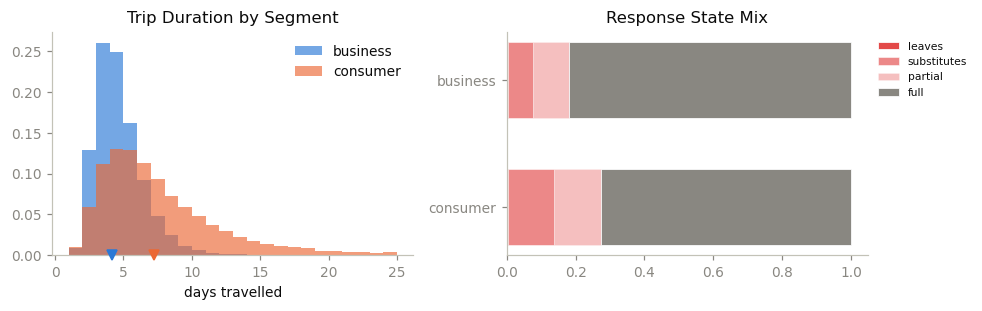

In [19]:
# Compare Business & Consumer
seg = trips.groupby('is_business').agg(
    trips = ('trip_id', 'size'),
    accounts = ('account_id', 'nunique'),
    avg_days = ('days_traveled', 'mean'),
    avg_party = ('lines_traveling', 'mean'),
    solo_share = ('lines_traveling', lambda s: (s == 1).mean()),
    no_purchase_rate = ('days_bought', lambda s: (s == 0).mean()),
    avg_revenue = ('pass_revenue', 'mean'),
).round(3)

seg.index = seg.index.map({False: 'consumer', True: 'business'})
print('Per Trip')
display(seg.rename_axis(None))

per_acct = (
    trips.groupby(['is_business', 'account_id'])
        .agg(trips = ('trip_id', 'size'), revenue = ('pass_revenue', 'sum'))
        .groupby('is_business').agg(
            accounts = ('trips', 'size'),
            trips_per_account = ('trips', 'mean'),
            revenue_per_account = ('revenue', 'mean'),
            revenue_p90 = ('revenue', lambda s: s.quantile(0.90)),
        ).round(2)
)

per_acct.index = per_acct.index.map({False: 'consumer', True: 'business'})
print('Per Account over the Full Window')
display(per_acct.rename_axis(None))

fig, axes = plt.subplots(1, 2, figsize = (9, 2.9))

for flag, label, color in [(True, 'business', ACCENT), (False, 'consumer', ACCENT2)]:
    sub = trips[trips.is_business == flag]
    
    axes[0].hist(
        sub['days_traveled'], bins = range(1, 26), alpha = 0.65,
        label = label, color = color, density = True
    )
    
    axes[0].plot(
        sub['days_traveled'].mean(), 0, marker = 'v', color = color,
        markersize = 6, clip_on = False, zorder = 5
    )
    
axes[0].set_title('Trip Duration by Segment')
axes[0].set_xlabel('days travelled')
axes[0].legend(frameon = False)

STATE_ORDER = ['leaves', 'substitutes', 'partial', 'full']

STATE_COLOR = {
    'leaves': RED, 'substitutes': RED, 'partial': RED, 'full': MUTED
}

STATE_ALPHA = {
    'leaves': 1.00, 'substitutes': 0.65, 'partial': 0.35, 'full': 1.00
}

state_mix = (
    trips.groupby('is_business')['state']
        .value_counts(normalize = True).unstack().fillna(0)
        .reindex(columns = STATE_ORDER)
)

state_mix.index = state_mix.index.map({False: 'consumer', True: 'business'})

left = np.zeros(len(state_mix))
for s in STATE_ORDER:
    
    axes[1].barh(
        state_mix.index, state_mix[s], left = left, height = 0.6,
        color = STATE_COLOR[s], alpha = STATE_ALPHA[s],
        edgecolor = SURFACE, linewidth = 0.5, label = s
    )
    
    left += state_mix[s].to_numpy()
    
axes[1].set_title('Response State Mix')
axes[1].legend(frameon = False, fontsize = 7, bbox_to_anchor = (1.0, 1.0))
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 1.3 Revenue Concentration

**Design Notes:**

1. Telecom revenue is heavily concentrated
2. Top decile should carry a disproportionate share
3. Otherwise: "the opportunity sits in a minority of travellers" would be a generator artefact, not a real finding
4. Chart: guards small populations where pct * len(cum) < 1

**Observations:**

1. Top 1% of accounts carry 11.8% of pass revenue
2. Top 10% of accounts carry 50.8%, over half the total from a tenth of the population
3. Top 50% of accounts carry 98.8%, confirming the bottom half is nearly irrelevant to revenue


,share of pass revenue
1%,11.8%
5%,33.8%
10%,50.8%
20%,72.3%
50%,98.8%


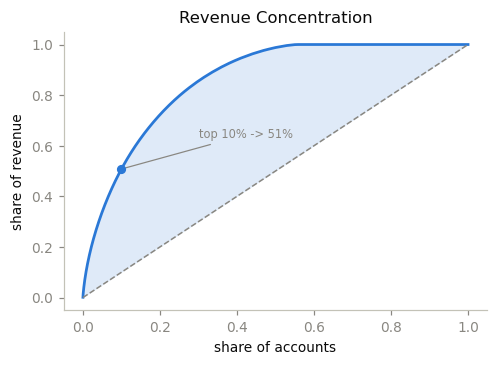

In [20]:
# Check Revenue Concentration
acct_rev = (
    trips.groupby('account_id')['pass_revenue'].sum()
        .reindex(all_accounts, fill_value = 0).sort_values(ascending = False)
)

cum = acct_rev.cumsum() / acct_rev.sum()
share_of_accounts = np.arange(1, len(cum) + 1) / len(cum)

concentration_rows = []
for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    i = max(int(pct * len(cum)) - 1, 0)
    concentration_rows.append({'top % of accounts': f'{pct:.0%}', 'share of pass revenue': f'{cum.iloc[i]:.1%}'})

display(pd.DataFrame(concentration_rows).set_index('top % of accounts').rename_axis(None))

fig, ax = plt.subplots(figsize = (4.6, 3.4))
ax.fill_between(share_of_accounts, cum.values, share_of_accounts, color = ACCENT, alpha = 0.15, linewidth = 0)
ax.plot(share_of_accounts, cum.values, color = ACCENT, linewidth = 1.8)
ax.plot([0, 1], [0, 1], color = MUTED, linewidth = 1, linestyle = '--')

i10 = max(int(0.10 * len(cum)) - 1, 0)
ax.plot(share_of_accounts[i10], cum.values[i10], marker = 'o', color = ACCENT, markersize = 5, zorder = 5)

ax.annotate(
    f'top 10% -> {cum.values[i10]:.0%}', xy = (share_of_accounts[i10], cum.values[i10]),
    xytext = (0.32, 0.62), textcoords = 'axes fraction', fontsize = 7.5, color = MUTED,
    arrowprops = dict(arrowstyle = '-', color = MUTED, lw = 0.8)
)

ax.set_xlabel('share of accounts')
ax.set_ylabel('share of revenue')
ax.set_title('Revenue Concentration')
plt.tight_layout()
plt.show()


### 1.4 Macro & Seasonality Signal

**Design Notes:**

1. Trip volume must track the macro index
2. Makes the forward simulation's correlated draws meaningful
3. If volume were independent of the economy, modeling macro scenarios later would be theatre
4. Chart: two panels sharing an x-axis instead of a dual-axis chart, which would imply a false alignment between two different scales

**Observations:**

1. Trip volume correlates with the macro index at 0.758, and with seasonality at 0.697
2. Revenue correlates with trip volume at 0.997, confirming revenue moves almost entirely with volume, not composition


,correlation
trip volume vs macro index,0.758
trip volume vs seasonality,0.697
revenue vs trip volume,0.997


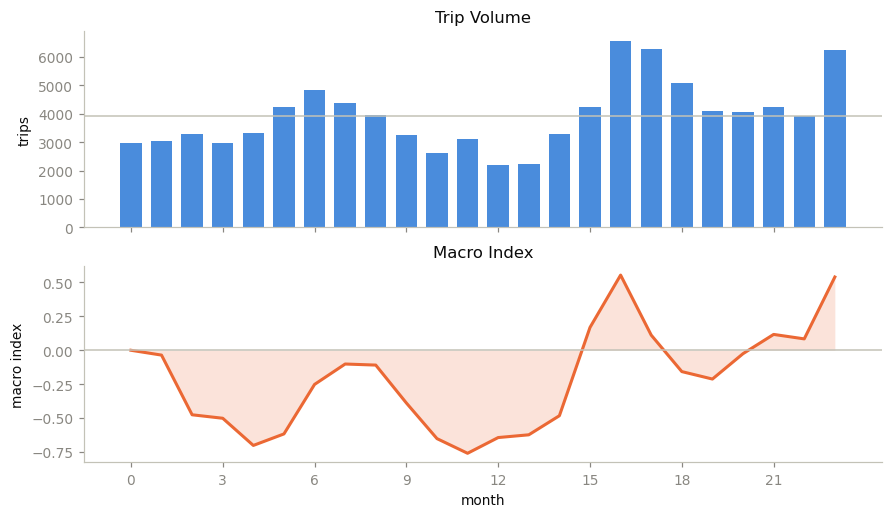

In [21]:
# Check Macro & Seasonality Signal
monthly = (
    trips.groupby('month')
        .agg(trips = ('trip_id', 'size'), revenue = ('pass_revenue', 'sum'))
        .reset_index().merge(macro, on = 'month')
)

display(pd.DataFrame({'correlation': [
    monthly.trips.corr(monthly.macro_index),
    monthly.trips.corr(monthly.seasonality),
    monthly.revenue.corr(monthly.trips),
]}, index = ['trip volume vs macro index', 'trip volume vs seasonality', 'revenue vs trip volume']).round(3))

fig, axes = plt.subplots(
    2, 1, figsize = (8, 4.6), sharex = True,
    gridspec_kw = {'height_ratios': [1, 1]}, layout = 'constrained',
)

axes[0].bar(monthly.month, monthly.trips, color = ACCENT, width = 0.7, alpha = 0.85)
axes[0].axhline(monthly.trips.mean(), color = BASELINE, linewidth = 1)
axes[0].set_ylabel('trips')
axes[0].set_title('Trip Volume')

axes[1].fill_between(monthly.month, 0, monthly.macro_index, color = ACCENT2, alpha = 0.18, linewidth = 0)
axes[1].plot(monthly.month, monthly.macro_index, color = ACCENT2, linewidth = 2)
axes[1].axhline(0, color = BASELINE, linewidth = 1)
axes[1].set_ylabel('macro index')
axes[1].set_xlabel('month')
axes[1].set_title('Macro Index')
axes[1].set_xticks(range(0, N_MONTHS, 3))

plt.show()


---
## 2 · Label Boundary Readability

**Purpose:** Determines whether the reduce/unchanged boundary is readable from observable data alone, since the five states are never labeled in production.

**Design Notes:**

1. Most important decision: in production the five states are not observed
2. Must be reconstructed from what is measurable:

| Observable | What it distinguishes |
:--|:--|
| days_bought == 0 | bought nothing: **substitutes** or **leaves** |
| days_bought / days_traveled | how much of the trip was covered |
| lines_active / lines_traveling | how much of the party was covered |

3. Hard boundary: **reduces vs unchanged**. Both bought the pass; the question is how far below full coverage counts as deliberate reduction
4. Bimodal coverage ratio (spike at 1.0 + separate spread below) → threshold reads off the valley
5. Smooth continuum → no threshold defensible; treat probabilistically instead

**Observations:**

1. 72.5% of purchasing trips sit at exactly full coverage (1.0)
2. 20.3% fall below full coverage, the candidate reduces population
3. 7.1% exceed full coverage (bought more days than travelled), consistent with the increases state


Day Coverage among Trips That Bought the Pass


,value
count,85013.000
mean,0.916
std,0.184
min,0.059
5%,0.500
25%,1.000
50%,1.000
75%,1.000
95%,1.000
max,1.000


,share of trips
exactly 1.0 (covered the trip),78.1%
below 1.0 (partial),21.9%


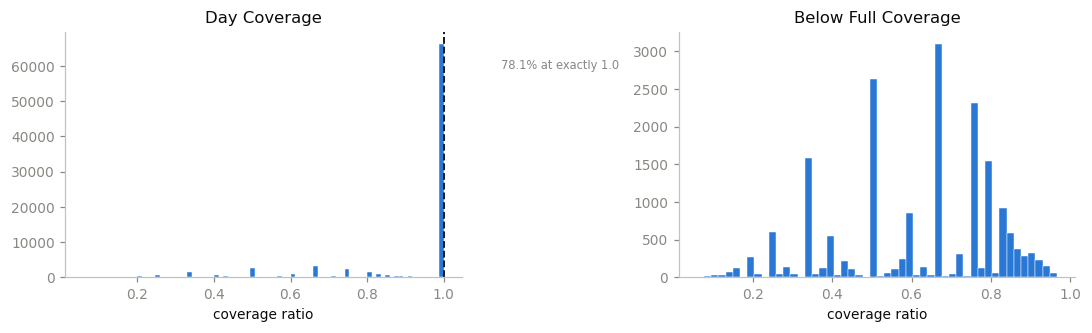

In [22]:
# Check Label Boundary
bought = trips[trips['days_bought'] > 0].copy()
bought['day_coverage'] = bought['days_bought'] / bought['days_traveled']
bought['line_coverage'] = bought['lines_active'] / bought['lines_traveling']

print('Day Coverage among Trips That Bought the Pass')
display(bought['day_coverage'].describe(percentiles = [.05, .25, .5, .75, .95]).round(3).to_frame('value'))
display(pd.DataFrame({'share of trips': [
    f"{(bought.day_coverage == 1).mean():.1%}",
    f"{(bought.day_coverage < 1).mean():.1%}",
]}, index = ['exactly 1.0 (covered the trip)', 'below 1.0 (partial)']))

fig, axes = plt.subplots(1, 2, figsize = (10, 3.1))

axes[0].hist(
    bought['day_coverage'].clip(0, 2), bins = 80, color = ACCENT,
    edgecolor = SURFACE, linewidth = 0.3
)

axes[0].axvline(1.0, color = INK, linewidth = 1.2, linestyle = '--')
exact_share = (bought.day_coverage == 1).mean()

axes[0].annotate(
    f'{exact_share:.1%} at exactly 1.0', xy = (1.0, axes[0].get_ylim()[1] * 0.92),
    xytext = (1.15, axes[0].get_ylim()[1] * 0.85), fontsize = 7.5, color = MUTED
)

axes[0].set_title('Day Coverage')
axes[0].set_xlabel('coverage ratio')

axes[1].hist(
    bought.loc[bought.day_coverage < 1, 'day_coverage'], bins = 50,
    color = ACCENT, edgecolor = SURFACE, linewidth = 0.3
)

axes[1].set_title('Below Full Coverage')
axes[1].set_xlabel('coverage ratio')

plt.tight_layout()
plt.show()


### 2.1 Testing Candidate Thresholds Against the Truth

**Design Notes:**

1. Synthetic data → true state is known → can score the labelling rule itself (impossible with real data)
2. Each rule applied as it would be in production (observables only), then compared against state
3. Three rules tested, not one: a coverage ratio alone conflates trip length
  - 1 day short on a 3-day trip = 0.67 ratio, likely incidental
  - 1 day short on a 10-day trip = 0.90 ratio, also likely incidental

| Rule | Reduces when |
|:--|:--|
| **ratio** | coverage falls below a cutoff |
| **absolute** | a fixed number of days went unbought, regardless of trip length |
| **combined** | materially short in days *and* below the ratio cutoff |

4. Accuracy is the wrong criterion: full dominates, so under-labelling partial still scores well
5. F1 on the minority class (partial) is the criterion the choice follows
6. null applied last in the rule, so it overrides the partial rule for days_bought == 0 rows
7. BEST_LABEL is not simply argmax(F1): recall matters more than precision, since missing a real reduction costs more than over-labelling one; derived from rule_params, not hand-typed, and checked against the F1 ranking

**Real-World Estimation:**

1. Real data has no state column to score candidate rules against; this comparison is only possible here because the ground truth was generated
2. In production, validating a labelling rule would need some independent source of truth for at least a small sample
  - A manually audited sample (e.g., customer service records or a survey), or a controlled pilot checking actual subsequent behavior
3. Without a true-label sample, the rule would be chosen on face validity and stability (does the cutoff choice meaningfully change results) rather than F1 against a known truth

**Observations:**

1. ratio < 0.7 wins outright: best F1 (0.782) and best accuracy (94.8%), rank 1 of 19 candidates
2. True share with partial coverage is 11.84%, and the chosen rule recovers it at 79.2% recall, 77.3% precision
3. Absolute and combined rules trade recall for precision (e.g. short >= 3d reaches 100% precision but only 42.2% recall), confirming a pure ratio cutoff is the better trade-off here


In [23]:
# Score Candidate Rules
def apply_rule(df, day_thresh, line_thresh = 0.999, rule = 'ratio', days_short = 2):
    
    days = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower=1)
    short = df['days_traveled'] - df['days_bought']

    if rule == 'ratio':
        is_reduce = days < day_thresh
    elif rule == 'absolute':
        is_reduce = short >= days_short
    elif rule == 'combined':
        is_reduce = (short >= days_short) & (days < day_thresh)
    else:
        raise ValueError(rule)

    out = pd.Series('full', index = df.index, dtype = object)
    out[is_reduce | (lines < line_thresh)] = 'partial'
    out[df['days_bought'] == 0] = 'null'
    
    return out

truth_pooled = trips['state'].replace({'substitutes': 'null', 'leaves': 'null'})

def score(pred, label):
    
    tp = ((pred == 'partial') & (truth_pooled == 'partial')).sum()
    
    return {
        'rule': label,
        'accuracy': (pred == truth_pooled).mean(),
        'recall': tp / max((truth_pooled == 'partial').sum(), 1),
        'precision': tp / max((pred == 'partial').sum(), 1),
        'share labelled': (pred == 'partial').mean(),
    }

rows, rule_params = [], {}
for t in [0.999, 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50, 0.40]:
    label = f'ratio < {t}'
    rule_params[label] = dict(day_thresh = t, rule = 'ratio')
    rows.append(score(apply_rule(trips, t, rule = 'ratio'), label))
    
for d in [1, 2, 3, 4]:
    label = f'short >= {d}d'
    rule_params[label] = dict(day_thresh = 1.0, rule = 'absolute', days_short = d)
    rows.append(score(apply_rule(trips, 1.0, rule = 'absolute', days_short = d), label))
    
for d in [2, 3]:
    for t in [0.95, 0.85, 0.75]:
        label = f'short >= {d}d and ratio < {t}'
        rule_params[label] = dict(day_thresh = t, rule = 'combined', days_short = d)
        rows.append(score(apply_rule(trips, t, rule = 'combined', days_short = d), label))

res = pd.DataFrame(rows).set_index('rule').round(4)
res['f1'] = (2 * res.precision * res.recall / (res.precision + res.recall)).round(4)
display(res.rename_axis(None))

true_share = (truth_pooled == 'partial').mean()
print(f'\nTrue Share Partial: {true_share:.4f}')
print(f'Best F1: {res.f1.idxmax()}  (F1 {res.f1.max():.3f})')
print(f'Best Accuracy: {res.accuracy.idxmax()} ({res.accuracy.max():.1%})')

BEST_LABEL = 'ratio < 0.7'
assert BEST_LABEL in res.index, f'{BEST_LABEL!r} not among the candidate rules tested above'

BEST_RULE = rule_params[BEST_LABEL]
best_rank = int(res.f1.rank(ascending = False)[BEST_LABEL])
print(f'\nChosen Rule: {BEST_LABEL}  ->  {BEST_RULE}')
print(
    f"F1 = {res.loc[BEST_LABEL, 'f1']:.3f}, precision = {res.loc[BEST_LABEL, 'precision']:.3f}, "
    f"recall = {res.loc[BEST_LABEL, 'recall']:.3f}  (rank {best_rank} of {len(res)} by F1)"
)
assert best_rank <= 3, (
    f'{BEST_LABEL!r} dropped to rank {best_rank} by F1, so the asymmetric-cost '
    'argument for choosing it over the top F1 rule no longer holds; re-pick BEST_RULE.'
)


,accuracy,recall,precision,share labelled,f1
ratio < 0.999,0.9103,0.9534,0.5729,0.1971,0.7157
ratio < 0.95,0.9109,0.9532,0.5747,0.1964,0.7171
ratio < 0.9,0.9172,0.9490,0.5942,0.1892,0.7308
ratio < 0.85,0.9268,0.9367,0.6281,0.1766,0.7520
ratio < 0.8,0.9414,0.8865,0.6992,0.1502,0.7818
ratio < 0.7,0.9478,0.7921,0.7730,0.1214,0.7824
ratio < 0.6,0.9451,0.6013,0.9029,0.0789,0.7219
ratio < 0.5,0.9228,0.3802,0.9227,0.0488,0.5385
ratio < 0.4,0.9138,0.3041,0.9052,0.0398,0.4553
short >= 1d,0.9103,0.9534,0.5729,0.1971,0.7157



True Share Partial: 0.1184
Best F1: ratio < 0.7  (F1 0.782)
Best Accuracy: ratio < 0.7 (94.8%)

Chosen Rule: ratio < 0.7  ->  {'day_thresh': 0.7, 'rule': 'ratio'}
F1 = 0.782, precision = 0.773, recall = 0.792  (rank 1 of 19 by F1)


In [24]:
# Show Confusion Table
pred = apply_rule(trips, **BEST_RULE)
confusion = pd.crosstab(truth_pooled, pred, normalize = 'index').round(3)

print('True State (rows) vs. Labelled State (columns)')
display(confusion.rename_axis(None).rename_axis(None, axis = 1))


True State (rows) vs. Labelled State (columns)


,full,null,partial
full,0.965,0.0,0.035
null,0.000,1.0,0.000
partial,0.208,0.0,0.792


**Reading the Confusion Table**

- Two failure modes, not symmetric
  1. Partial labelled full → understates price damage; revenue case looks optimistic
  2. Full labelled partial → overstates damage; recommendation becomes needlessly timid
- Given the decision at stake, the second error is safer
- Threshold chosen accordingly, not purely for accuracy

**On no_purchase**

- Substitutes and leaves can't be separated at trip level: both look like null coverage
- Pooled into `null` here deliberately
- Splitting requires account-level departure evidence; it belongs in the modelling notebook, not the labelling rule

**Observations:**

1. null is recovered perfectly (100% on the diagonal), since days_bought == 0 needs no threshold judgment
2. partial is correctly labelled 79.2% of the time; the remaining 20.8% falls to full (understating price damage, the safer error)
3. full is correctly labelled 96.5% of the time; only 3.5% is mislabelled as partial


---
## 3 · Price Variation per Segment

**Purpose:** Confirms every business/party-size segment has enough off-standard price exposure to estimate a response, since a segment with no variation silently inherits the population average instead of raising an error.

**Design Notes:**

1. Price response can only be estimated where price actually moved
2. Looks fine overall; frequently fails per segment
3. A segment with no variation silently inherits the population average
4. Invisible in model metrics: surfaces only when pricing a group the model never had evidence for
5. Minimum cell size for a segment's response to be estimable: 300 trips
6. Signal check: no-purchase rate by segment and price, the raw pattern the model must find

**Observations:**

1. 33.1% of trips face a non-standard rate overall, and every segment sits close to that (32.7%-34.1%)
2. business / pair falls below the 300-trip minimum at all four off-standard price points (187-285 trips each), the one segment where sensitivity will not be reliably estimable
3. No-purchase rate rises with price in every segment, confirming the raw signal is present everywhere, including the thin business / pair cells


In [25]:
# Check Price Exposure
print('Overall Price Exposure')
display(
    trips['price_multiplier'].value_counts(normalize = True).sort_index().round(4)
        .to_frame('share of trips').rename_axis(None)
)

print(f'Share of Trips off the Standard Rate: {(trips.price_multiplier != 1.0).mean():.1%}')
trips['party_band'] = pd.cut(
    trips['lines_traveling'], [0, 1, 2, 10], labels = ['solo', 'pair', '3+']
)

trips['segment'] = (
    pd.Series(np.where(trips.is_business, 'business', 'consumer'),
    index=trips.index).str.cat(trips.party_band.astype(str), sep=' / ')
)

variation = trips.pivot_table(
    index = 'segment', columns = 'price_multiplier',
    values = 'trip_id', aggfunc = 'count'
).fillna(0).astype(int)

variation['total'] = variation.sum(axis = 1)
variation['off-standard %'] = (1 - variation[1.0] / variation['total']).round(3)

print('Trips by Segment & Price Multiplier')
display(variation.rename_axis(None).rename_axis(None, axis = 1))


Overall Price Exposure


,share of trips
0.90,0.0711
0.95,0.0851
1.00,0.6687
1.10,0.1064
1.20,0.0687


Share of Trips off the Standard Rate: 33.1%
Trips by Segment & Price Multiplier


,0.9,0.95,1.0,1.1,1.2,total,off-standard %
business / 3+,347,422,3301,561,379,5010,0.341
business / pair,196,225,1827,285,187,2720,0.328
business / solo,3312,3928,31001,4959,3180,46380,0.332
consumer / 3+,418,501,4038,635,408,6000,0.327
consumer / pair,628,745,5741,904,594,8612,0.333
consumer / solo,1821,2224,17340,2721,1751,25857,0.329


In [26]:
# Check Cell Sizes
MIN_CELL = 300

cells = (
    trips.groupby(['segment', 'price_multiplier']).size()
        .rename('n').reset_index()
)

thin = cells[cells.n < MIN_CELL]

if thin.empty:
    print(f'All segment x price cells have at least {MIN_CELL} trips.')
    
else:
    print(f'Cells Below {MIN_CELL} Trips (sensitivity here will not be estimable):')
    display(thin.sort_values('n').set_index(['segment', 'price_multiplier']).rename_axis([None, None]))

print('No-Purchase Rate by Segment & Price (the raw signal the model must find):')

signal = trips.pivot_table(
    index = 'segment', columns = 'price_multiplier',
    values = 'days_bought', aggfunc = lambda s: (s == 0).mean()
).round(3)

display(signal.rename_axis(None).rename_axis(None, axis = 1))


Cells Below 300 Trips (sensitivity here will not be estimable):


n
business / pair 1.20  187
                0.90  196
                0.95  225
                1.10  285

No-Purchase Rate by Segment & Price (the raw signal the model must find):


,0.90,0.95,1.00,1.10,1.20
business / 3+,0.069,0.059,0.072,0.078,0.084
business / pair,0.051,0.089,0.071,0.088,0.080
business / solo,0.075,0.070,0.072,0.086,0.096
consumer / 3+,0.117,0.130,0.128,0.167,0.235
consumer / pair,0.091,0.121,0.126,0.168,0.205
consumer / solo,0.115,0.118,0.126,0.176,0.226


### 3.1 Intentional Confounding

**Design Notes:**

1. Price multiplier assigned by region and period, not at random
2. Heavy travellers, specific destinations, and higher-price windows overlap
3. Naive comparison would attribute those differences to price
4. Check below quantifies how much
5. Raw vs. within-segment difference disagreeing → modelling notebook must control for it

**Observations:**

1. Europe/Asia-Pacific share is heavily confounded with price: 88.0% of high-price trips vs. 43.1% of standard-price trips
2. Business share and average days are nearly identical across price levels (57.7% vs 57.1%; 5.46 vs 5.49 days), so those two are not meaningfully confounded
3. Raw no-purchase difference is +3.75 points; within segment x region it drops to +1.79 points, so confounding accounts for +1.96 points (52% of the raw effect)


In [27]:
# Check Confounding
high = trips[trips.price_multiplier >= 1.10]
base = trips[trips.price_multiplier == 1.0]

print('Naive Comparison, High Price vs. Standard')
display(pd.DataFrame({
    'high price (>=1.10)': [
        high.is_business.mean(),
        high.region.isin(['europe', 'asia', 'oceania']).mean(),
        high.days_traveled.mean(),
    ],
    'standard (1.00)': [
        base.is_business.mean(),
        base.region.isin(['europe', 'asia', 'oceania']).mean(),
        base.days_traveled.mean(),
    ],
}, index = ['business share', 'europe/asia-pacific share', 'avg days travelled']).round(3))

raw = high.days_bought.eq(0).mean() - base.days_bought.eq(0).mean()

within = []
for (seg_, reg), g in trips.groupby(['segment', 'region']):
    h = g[g.price_multiplier >= 1.10]
    b = g[g.price_multiplier == 1.0]
    if len(h) >= 100 and len(b) >= 100:
        within.append((h.days_bought.eq(0).mean() - b.days_bought.eq(0).mean(), len(h) + len(b)))

if within:
    diffs, weights = zip(*within)
    within_avg = np.average(diffs, weights = weights)
    print('No-Purchase Rate Difference, High Price vs. Standard')
    
    display(pd.DataFrame(
        {'no-purchase rate difference': [raw, within_avg, raw - within_avg]},
        index = ['raw', 'within segment x region', 'confounding accounts for']
    ).round(4))
    

Naive Comparison, High Price vs. Standard


,high price (>=1.10),standard (1.00)
business share,0.577,0.571
europe/asia-pacific share,0.880,0.431
avg days travelled,5.464,5.488


No-Purchase Rate Difference, High Price vs. Standard


,no-purchase rate difference
raw,0.0375
within segment x region,0.0180
confounding accounts for,0.0195


---
## 4 · Recovering the Truth

**Purpose:** Confirms observed behavior actually carries the latent sensitivity signal, the final check only possible because this is synthetic data with a known ground truth.

**Design Notes:**

1. Accounts bucketed by true sensitivity decile, behavior compared
  - Most/least sensitive deciles behave identically at higher prices → generator needs stronger signal
  - Clean separation → signal present; a later failure to find it is a modelling problem
2. Read value per account, not per trip
  - Sensitivity correlates with travel frequency; least-sensitive accounts are business, short/solo trips
  - Per-trip revenue runs inverse to insensitivity, inverting the finding
  - Any "upside sits with high-value, price-insensitive customers" claim must be made per account
3. Per-account table uses the full window (gt), not just high_price, since account value is not limited to elevated-price trips

**Real-World Estimation:**

1. This entire check depends on a known ground truth price_sensitivity, which doesn't exist in real data
2. In production, sensitivity would be the model's own fitted output (from the state model), not a value to check against
3. Validation would instead rely on indirect evidence: fitted sensitivity should point in the same business-plausible directions used here (frequent business travelers less sensitive), and hold up out-of-sample

**Observations:**

1. No-purchase rate at elevated prices trends down from 21.3% (decile 0, most sensitive) to 7.9% (decile 9, least sensitive)
2. Spread of +0.134 between the most and least sensitive deciles confirms the signal is present and learnable
3. Revenue per account rises with insensitivity (from 138.95 to 261.22), the confound noted above: least-sensitive accounts are also the most valuable and frequent


Behaviour at Elevated Prices, by True Sensitivity Decile (decile 0 = most sensitive)


,trips,no_purchase,avg_coverage,avg_revenue
0,771,0.213,4.572,67.556
1,764,0.190,4.860,72.728
2,855,0.216,4.822,70.328
3,925,0.204,4.904,70.028
4,985,0.184,4.871,71.285
5,1084,0.172,4.820,69.001
6,1340,0.143,4.496,64.012
7,1858,0.126,3.999,56.090
8,3127,0.108,3.468,46.143
9,4855,0.079,3.564,46.940


Value per Account by Sensitivity Decile (the unit a price decision uses)


,accounts,trips_per_account,revenue_per_account
0,2339,1.87,138.95
1,2411,1.89,139.99
2,2451,1.98,143.69
3,2555,1.99,141.98
4,2587,2.11,150.43
5,2693,2.41,158.80
6,2921,2.66,166.49
7,3215,3.45,183.51
8,3850,4.59,204.90
9,4384,6.22,261.22


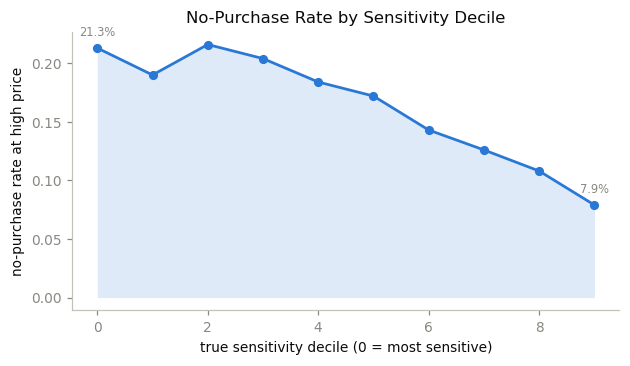


Spread, most vs least sensitive decile: +0.134
Signal is present and learnable.


In [28]:
# Check Signal Recovery
gt = trips.merge(ground_truth[['account_id', 'sensitivity_decile']], on='account_id')
high_price = gt[gt.price_multiplier >= 1.10]

by_decile = high_price.groupby('sensitivity_decile').agg(
    trips = ('trip_id', 'size'),
    no_purchase = ('days_bought', lambda s: (s == 0).mean()),
    avg_coverage = ('days_bought', 'mean'),
    avg_revenue = ('pass_revenue', 'mean'),
).round(3)

print('Behaviour at Elevated Prices, by True Sensitivity Decile (decile 0 = most sensitive)')
display(by_decile.rename_axis(None))

acct_decile = (
    gt.groupby(['sensitivity_decile', 'account_id'])
       .agg(trips = ('trip_id', 'size'), revenue = ('pass_revenue', 'sum'))
       .groupby('sensitivity_decile').agg(
           accounts = ('trips', 'size'),
           trips_per_account = ('trips', 'mean'),
           revenue_per_account = ('revenue', 'mean'),
        ).round(2)
)
print('Value per Account by Sensitivity Decile (the unit a price decision uses)')
display(acct_decile.rename_axis(None))

fig, ax = plt.subplots(figsize=(5.8, 3.4))
ax.fill_between(by_decile.index, 0, by_decile.no_purchase, color = ACCENT, alpha = 0.15, linewidth = 0)
ax.plot(by_decile.index, by_decile.no_purchase, marker = 'o', color = ACCENT, linewidth = 1.8, markersize = 5)

first_v = by_decile.no_purchase.iloc[0]
last_v = by_decile.no_purchase.iloc[-1]

ax.annotate(
    f'{first_v:.1%}', xy = (by_decile.index[0], first_v), xytext = (0, 8),
    textcoords = 'offset points', ha = 'center', fontsize = 7.5, color = MUTED
)

ax.annotate(
    f'{last_v:.1%}', xy = (by_decile.index[-1], last_v), xytext = (0, 8),
    textcoords = 'offset points', ha = 'center', fontsize = 7.5, color = MUTED
)

ax.set_xlabel('true sensitivity decile (0 = most sensitive)')
ax.set_ylabel('no-purchase rate at high price')
ax.set_title('No-Purchase Rate by Sensitivity Decile')
plt.tight_layout()
plt.show()

spread = by_decile.no_purchase.iloc[0] - by_decile.no_purchase.iloc[-1]
print(f'\nSpread, most vs least sensitive decile: {spread:+.3f}')
print(
    'Signal is present and learnable.' if abs(spread) > 0.05 
        else 'Signal too weak; increase sensitivity dispersion in Part 1 above.'
)
